In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/Bengaluru_House_Data.csv")

df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [25]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()


Dataset Shape: (13320, 9)

Columns:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 936.7 KB


In [26]:
df.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [27]:
df = df.drop(['society', 'availability'], axis=1)

df.head()

,area_type,location,size,total_sqft,bath,balcony,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [28]:
df = df.dropna(subset=['location', 'size', 'bath'])

df['balcony'] = df['balcony'].fillna(df['balcony'].median())

df.isnull().sum()


area_type     0
location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [29]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

df[['size', 'bhk']].head(10)


,size,bhk
0,2 BHK,2
1,4 Bedroom,4
2,3 BHK,3
3,3 BHK,3
4,2 BHK,2
5,2 BHK,2
6,4 BHK,4
7,4 BHK,4
8,3 BHK,3
9,6 Bedroom,6


In [30]:
df = df.drop('size', axis=1)

df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Plot Area,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Built-up Area,Uttarahalli,1440,2.0,3.0,62.00,3
3,Super built-up Area,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Super built-up Area,Kothanur,1200,2.0,1.0,51.00,2


In [31]:
def is_float(x):
    try:
        float(x)
        return True
    except:
        return False

df[~df['total_sqft'].apply(is_float)].head(20)

,area_type,location,total_sqft,bath,balcony,price,bhk
30,Super built-up Area,Yelahanka,2100 - 2850,4.0,0.0,186.000,4
122,Super built-up Area,Hebbal,3067 - 8156,4.0,0.0,477.000,4
137,Super built-up Area,8th Phase JP Nagar,1042 - 1105,2.0,0.0,54.005,2
165,Super built-up Area,Sarjapur,1145 - 1340,2.0,0.0,43.490,2
188,Super built-up Area,KR Puram,1015 - 1540,2.0,0.0,56.800,2
410,Super built-up Area,Kengeri,34.46Sq. Meter,1.0,0.0,18.500,1
549,Super built-up Area,Hennur Road,1195 - 1440,2.0,0.0,63.770,2
648,Built-up Area,Arekere,4125Perch,9.0,2.0,265.000,9
661,Super built-up Area,Yelahanka,1120 - 1145,2.0,0.0,48.130,2
672,Built-up Area,Bettahalsoor,3090 - 5002,4.0,0.0,445.000,4


In [32]:
def convert_sqft_to_num(x):
    tokens = x.split('-')
    
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    
    try:
        return float(x)
    except:
        return None

In [34]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

AttributeError: 'float' object has no attribute 'split'

In [35]:
df['total_sqft'].isnull().sum()

np.int64(46)

In [ ]:
df = df.dropna(subset=['total_sqft'])

In [ ]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

df.head()

Dataset shape: (13200, 7)

Missing values:
area_type     0
location      0
total_sqft    0
bath          0
balcony       0
price         0
bhk           0
dtype: int64


,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2


In [ ]:
df.shape

(13200, 7)

In [ ]:
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000


In [ ]:
df['price_per_sqft'].describe()

count    1.320000e+04
mean     7.920759e+03
std      1.067272e+05
min      2.678298e+02
25%      4.267701e+03
50%      5.438331e+03
75%      7.317073e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [ ]:
df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']

df['sqft_per_bhk'].describe()

count    13200.000000
mean       573.847262
std        388.079980
min          0.250000
25%        473.000000
50%        552.000000
75%        625.000000
max      26136.000000
Name: sqft_per_bhk, dtype: float64

In [ ]:
df[df['sqft_per_bhk'] < 300].head(10)

,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
9,Plot Area,Gandhi Bazar,1020.0,6.0,2.0,370.0,6,36274.509804,170.000000
45,Plot Area,HSR Layout,600.0,9.0,2.0,200.0,8,33333.333333,75.000000
58,Plot Area,Murugeshpalya,1407.0,4.0,1.0,150.0,6,10660.980810,234.500000
68,Plot Area,Devarachikkanahalli,1350.0,7.0,0.0,85.0,8,6296.296296,168.750000
70,Plot Area,Double Road,500.0,3.0,2.0,100.0,3,20000.000000,166.666667
78,Built-up Area,Kaval Byrasandra,460.0,1.0,0.0,22.0,2,4782.608696,230.000000
89,Plot Area,Rajaji Nagar,710.0,6.0,3.0,160.0,6,22535.211268,118.333333
119,Plot Area,Hennur Road,276.0,3.0,3.0,23.0,2,8333.333333,138.000000
129,Plot Area,Vishwapriya Layout,950.0,7.0,0.0,115.0,7,12105.263158,135.714286
149,Plot Area,Dinnur,1034.0,5.0,2.0,185.0,6,17891.682785,172.333333


In [ ]:
df = df[df['total_sqft'] / df['bhk'] >= 300]

In [36]:
df['total_sqft'].dtype

dtype('float64')

In [37]:
df.shape

(13246, 7)

In [38]:
df['price_per_sqft'] = df['price'] * 100000 / df['total_sqft']

df['sqft_per_bhk'] = df['total_sqft'] / df['bhk']

df.head()

,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
0,Super built-up Area,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606,528.0
1,Plot Area,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615,650.0
2,Built-up Area,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556,480.0
3,Super built-up Area,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861,507.0
4,Super built-up Area,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000,600.0


In [39]:
df = df[df['sqft_per_bhk'] >= 300]

df.shape

(12456, 9)

In [40]:
df['location'] = df['location'].apply(lambda x: x.strip())

location_stats = df['location'].value_counts()

location_stats

location
Whitefield                                         532
Sarjapur  Road                                     388
Electronic City                                    295
Kanakpura Road                                     262
Thanisandra                                        234
                                                  ... 
Prasanna layout Herohalli                            1
Sarvobhogam Nagar                                    1
12th cross srinivas nagar banshankari 3rd stage      1
Havanur extension                                    1
Abshot Layout                                        1
Name: count, Length: 1205, dtype: int64

In [41]:
print("Unique locations:", df['location'].nunique())

Unique locations: 1205


In [42]:
rare_locations = location_stats[location_stats <= 10].index

df['location'] = df['location'].apply(
    lambda x: 'other' if x in rare_locations else x
)

print("Unique locations after grouping:", df['location'].nunique())

Unique locations after grouping: 223


In [43]:
def remove_pps_outliers(df):
    df_out = pd.DataFrame()

    for location, location_df in df.groupby('location'):
        mean = location_df['price_per_sqft'].mean()
        std = location_df['price_per_sqft'].std()

        filtered_df = location_df[
            (location_df['price_per_sqft'] > (mean - std)) &
            (location_df['price_per_sqft'] <= (mean + std))
        ]

        df_out = pd.concat([df_out, filtered_df], ignore_index=True)

    return df_out

df = remove_pps_outliers(df)

In [44]:
df.shape

(10316, 9)

In [45]:
df[df['bath'] > df['bhk'] + 2].head(10)

,area_type,location,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
1605,Built-up Area,Chikkabanavar,2460.0,7.0,2.0,80.0,4,3252.032520,615.000000
6665,Super built-up Area,Thanisandra,1806.0,6.0,2.0,116.0,3,6423.034330,602.000000
8378,Super built-up Area,other,11338.0,9.0,1.0,1000.0,6,8819.897689,1889.666667
9954,Built-up Area,other,7000.0,8.0,2.0,450.0,4,6428.571429,1750.000000


In [46]:
df = df[df['bath'] <= df['bhk'] + 2]

df.shape

(10312, 9)

In [47]:
print("Final Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Final Shape: (10312, 9)

Missing Values:
area_type         0
location          0
total_sqft        0
bath              0
balcony           0
price             0
bhk               0
price_per_sqft    0
sqft_per_bhk      0
dtype: int64

Duplicate Rows: 690


In [48]:
df.describe()

,total_sqft,bath,balcony,price,bhk,price_per_sqft,sqft_per_bhk
count,10312.000000,10312.000000,10312.000000,10312.000000,10312.000000,10312.000000,10312.000000
mean,1503.443241,2.474011,1.605896,90.598287,2.573798,5645.000621,582.881105
std,871.733779,0.978532,0.789218,84.819453,0.901396,2225.290910,214.734651
min,300.000000,1.000000,0.000000,10.000000,1.000000,1250.000000,300.000000
25%,1108.000000,2.000000,1.000000,49.000000,2.000000,4237.918216,495.000000
50%,1280.500000,2.000000,2.000000,67.000000,2.000000,5172.413793,562.500000
75%,1650.000000,3.000000,2.000000,100.000000,3.000000,6425.802071,625.000000
max,30400.000000,16.000000,3.000000,2200.000000,16.000000,24000.000000,10030.000000


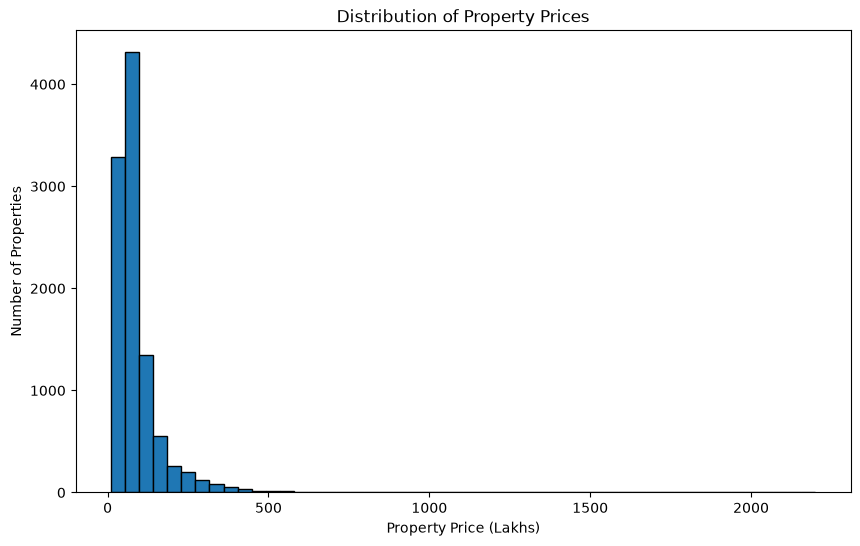

In [49]:
plt.figure(figsize=(10, 6))

plt.hist(df['price'], bins=50, edgecolor='black')

plt.xlabel('Property Price (Lakhs)')
plt.ylabel('Number of Properties')
plt.title('Distribution of Property Prices')

plt.show()

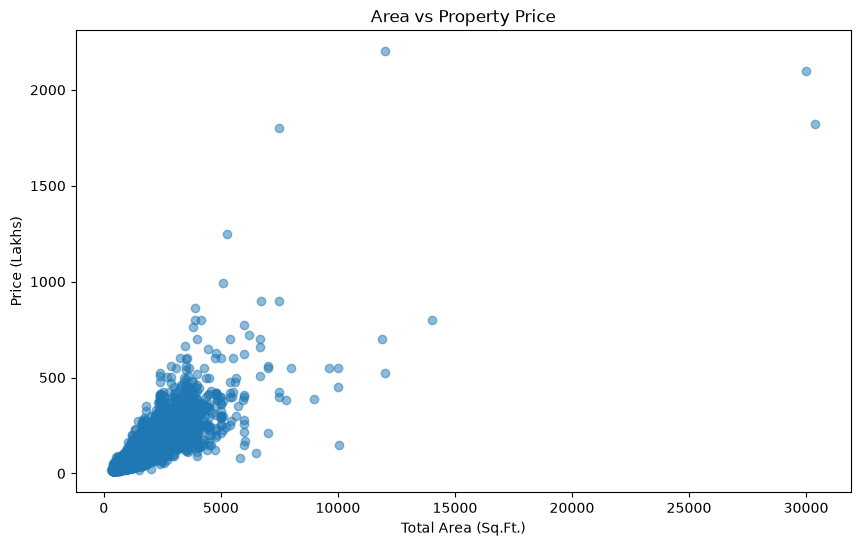

In [50]:
plt.figure(figsize=(10, 6))

plt.scatter(df['total_sqft'], df['price'], alpha=0.5)

plt.xlabel('Total Area (Sq.Ft.)')
plt.ylabel('Price (Lakhs)')
plt.title('Area vs Property Price')

plt.show()

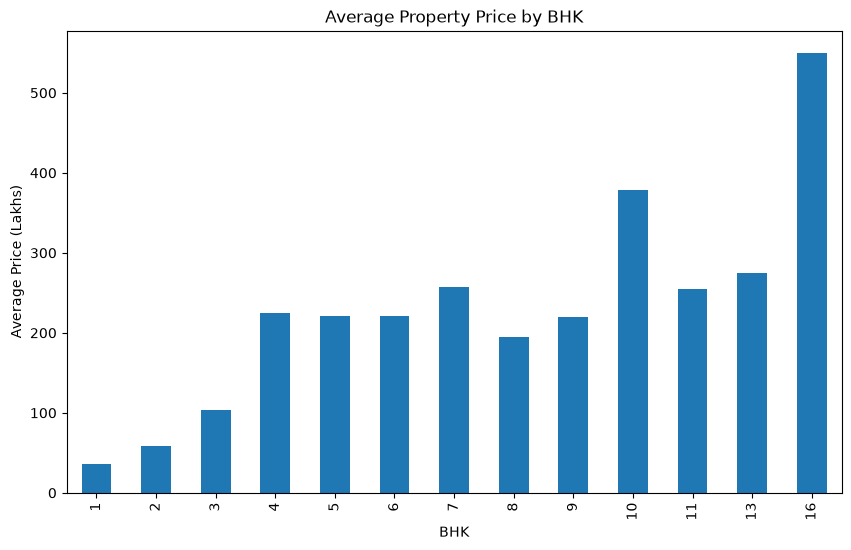

In [51]:
bhk_price = df.groupby('bhk')['price'].mean()

plt.figure(figsize=(10, 6))

bhk_price.plot(kind='bar')

plt.xlabel('BHK')
plt.ylabel('Average Price (Lakhs)')
plt.title('Average Property Price by BHK')

plt.show()

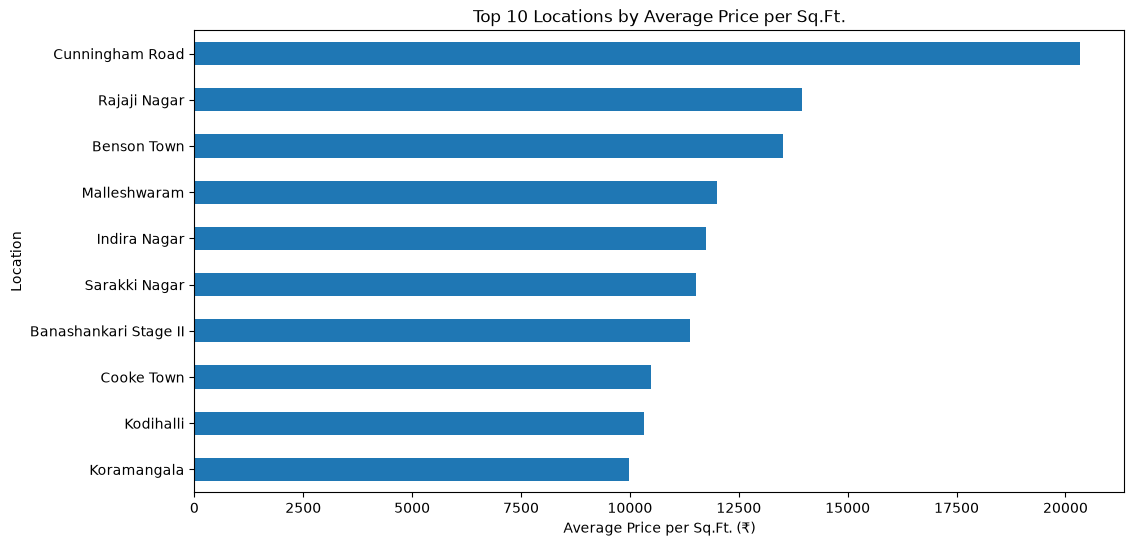

In [52]:
location_price = (
    df[df['location'] != 'other']
    .groupby('location')['price_per_sqft']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

location_price.sort_values().plot(kind='barh')

plt.xlabel('Average Price per Sq.Ft. (₹)')
plt.ylabel('Location')
plt.title('Top 10 Locations by Average Price per Sq.Ft.')

plt.show()

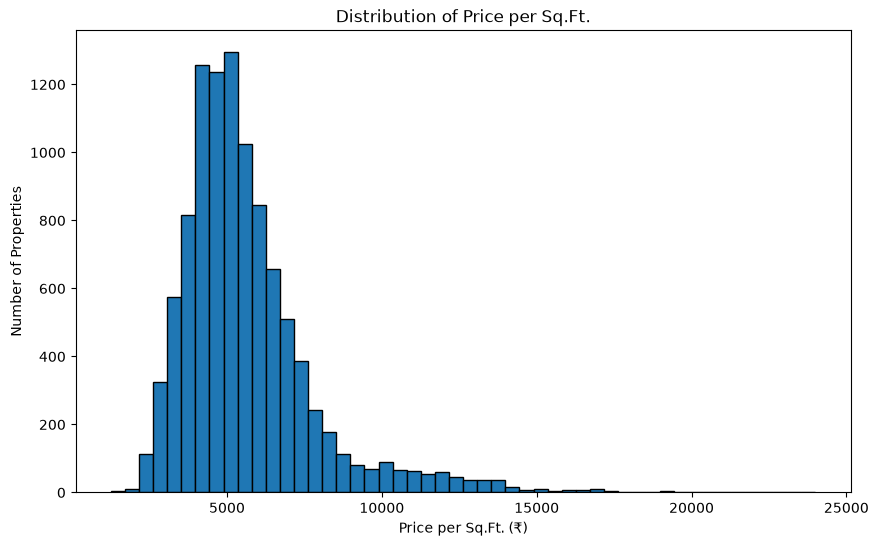

In [53]:
plt.figure(figsize=(10, 6))

plt.hist(df['price_per_sqft'], bins=50, edgecolor='black')

plt.xlabel('Price per Sq.Ft. (₹)')
plt.ylabel('Number of Properties')
plt.title('Distribution of Price per Sq.Ft.')

plt.show()

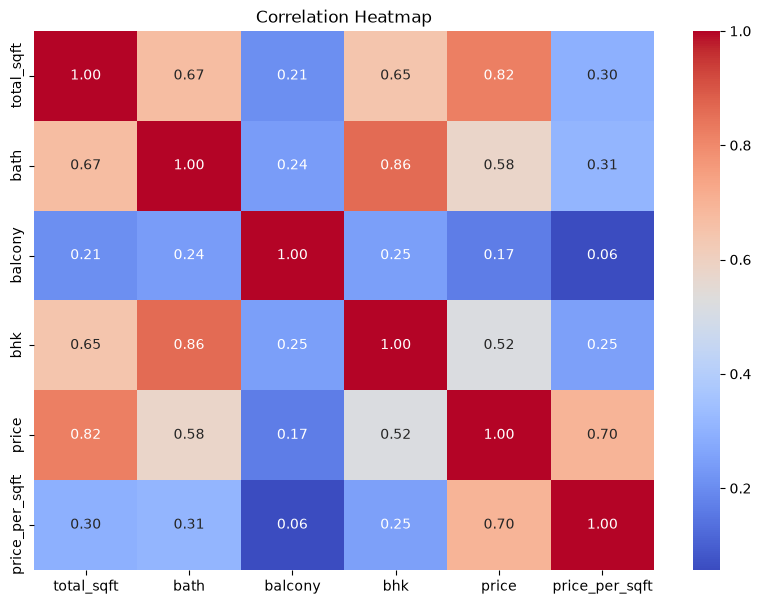

In [54]:
import seaborn as sns

numeric_cols = [
    'total_sqft',
    'bath',
    'balcony',
    'bhk',
    'price',
    'price_per_sqft'
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [55]:
df_ml = df.copy()

df_ml = df_ml.drop(['price_per_sqft', 'sqft_per_bhk'], axis=1)

df_ml.head()

,area_type,location,total_sqft,bath,balcony,price,bhk
0,Super built-up Area,1st Phase JP Nagar,2825.0,4.0,3.0,250.0,4
1,Super built-up Area,1st Phase JP Nagar,1875.0,3.0,1.0,167.0,3
2,Built-up Area,1st Phase JP Nagar,1500.0,5.0,2.0,85.0,5
3,Super built-up Area,1st Phase JP Nagar,2065.0,4.0,1.0,210.0,3
4,Super built-up Area,1st Phase JP Nagar,2024.0,3.0,2.0,157.0,3


In [56]:
df_ml = pd.get_dummies(
    df_ml,
    columns=['location', 'area_type'],
    drop_first=True
)

df_ml.head()

,total_sqft,bath,balcony,price,bhk,location_2nd Phase Judicial Layout,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,location_8th Phase JP Nagar,...,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area
0,2825.0,4.0,3.0,250.0,4,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1875.0,3.0,1.0,167.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1500.0,5.0,2.0,85.0,5,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,2065.0,4.0,1.0,210.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2024.0,3.0,2.0,157.0,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [57]:
X = df_ml.drop('price', axis=1)

y = df_ml['price']

In [58]:
print(X.shape)
print(y.shape)

(10312, 229)
(10312,)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8249, 229)
(2063, 229)


In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](229,)","[ 0.07, 8.5 , 0.31,..., 7.78,22.32, 2.39]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](229,)","['total_sqft','bath','balcony',...,'area_type_Carpet Area', 'area_type_Plot Area','area_type_Super built-up Area']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.522
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,229
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(229)


In [62]:
lr_predictions = lr.predict(X_test)

In [64]:
import sklearn
print(sklearn.__version__)

1.9.0


In [65]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, lr_predictions)
rmse = root_mean_squared_error(y_test, lr_predictions)
r2 = r2_score(y_test, lr_predictions)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 19.52
RMSE: 35.61
R²  : 0.7852


In [66]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=20
)

dt.fit(X_train, y_train)

dt_predictions = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_rmse = root_mean_squared_error(y_test, dt_predictions)
dt_r2 = r2_score(y_test, dt_predictions)

print(f"MAE : {dt_mae:.2f}")
print(f"RMSE: {dt_rmse:.2f}")
print(f"R²  : {dt_r2:.4f}")

MAE : 21.30
RMSE: 52.83
R²  : 0.5270


In [67]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_predictions = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = root_mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"MAE : {rf_mae:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R²  : {rf_r2:.4f}")

MAE : 16.69
RMSE: 34.80
R²  : 0.7948


In [68]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse
    ],
    "R² Score": [
        r2,
        dt_r2,
        rf_r2
    ]
})

results = results.sort_values(
    by="R² Score",
    ascending=False
)

results

,Model,MAE,RMSE,R² Score
2,Random Forest,16.691020,34.803116,0.794757
0,Linear Regression,19.516634,35.608114,0.785152
1,Decision Tree,21.302997,52.833631,0.527008


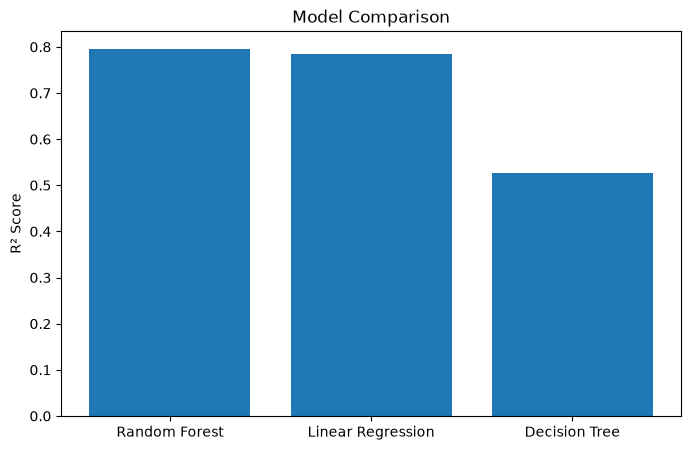

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R² Score"])

plt.ylabel("R² Score")
plt.title("Model Comparison")

plt.show()

In [70]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(rf, "../model/house_price_model.pkl")

joblib.dump(list(X.columns), "../model/model_columns.pkl")

print("✅ Model Saved Successfully")

✅ Model Saved Successfully
